In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [31]:
# 1. Load your dataset
df = pd.read_csv(r"C:\Users\hi\Downloads\archive (4)\energy_dataset.csv")
df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


Step 2: Time-Series Indexing (The Datetime Fix): We converted the plain text timestamps into a true Python DatetimeIndex format using pd.to_datetime().Why it matters: Computers treat raw dates like text strings (like "2026-05-24"). By converting them to Datetime objects, we unlocked the ability to ask the data structural questions like, "What hour of the day was this?" or "Was this a weekend?"

In [13]:
# 2. Convert the 'time' column to datetime formats explicitly
df['time'] = pd.to_datetime(df['time'], utc=True)

# 3. Set it as the index
df.set_index('time', inplace=True)


Empty DataFrame
Columns: [total load actual, load_lag_24h, hour]
Index: []


In [35]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['load_lag_24h'] = df[target_col].shift(24)


In [39]:
df[target_col] = df[target_col].ffill().bfill()
df['load_lag_24h'] = df['load_lag_24h'].ffill().bfill()
print(f" Cleaned data total rows: {len(df)}")

 Cleaned data total rows: 35064


In [43]:
features = ['hour', 'day_of_week', 'month', 'is_weekend', 'load_lag_24h']
X = df[features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"📉 Training on {len(X_train)} rows. Testing on {len(X_test)} rows.")

model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)


📉 Training on 28051 rows. Testing on 7013 rows.


In [55]:
print( f"\nMean Absolute Error (MAE): {mae:.2f} MW")


Mean Absolute Error (MAE): 1682.67 MW


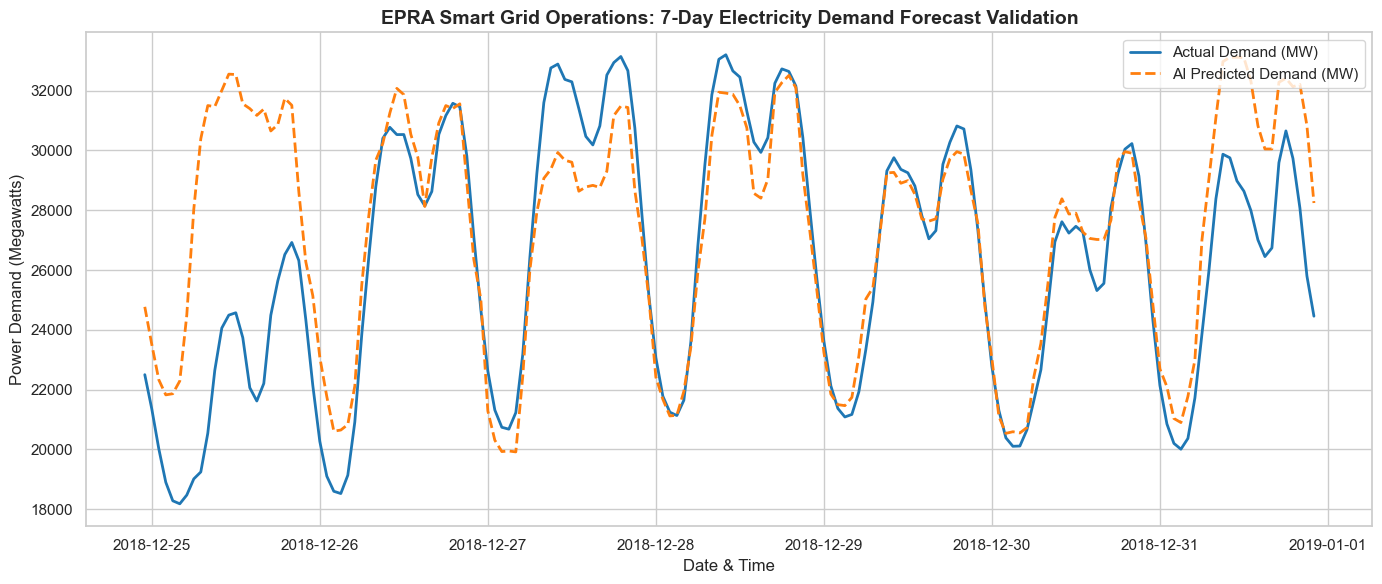

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for comparison using the test set index
comparison_df = pd.DataFrame(index=X_test.index)
comparison_df['Actual Demand'] = y_test
comparison_df['Model Prediction'] = predictions

# Zoom in on the last 7 days (168 hours) to make the chart highly readable
recent_days = comparison_df.tail(168)

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Plot Actual vs Predicted
plt.plot(recent_days.index, recent_days['Actual Demand'], label='Actual Demand (MW)', color='#1f77b4', linewidth=2)
plt.plot(recent_days.index, recent_days['Model Prediction'], label='AI Predicted Demand (MW)', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title('EPRA Smart Grid Operations: 7-Day Electricity Demand Forecast Validation', fontsize=14, fontweight='bold')
plt.xlabel('Date & Time', fontsize=12)
plt.ylabel('Power Demand (Megawatts)', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()


C:\Users\hi\AppData\Local\Temp\ipykernel_5264\1311525860.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Impact Score (%)', y='Regulatory Driver Factor', data=importance_df, palette='viridis')


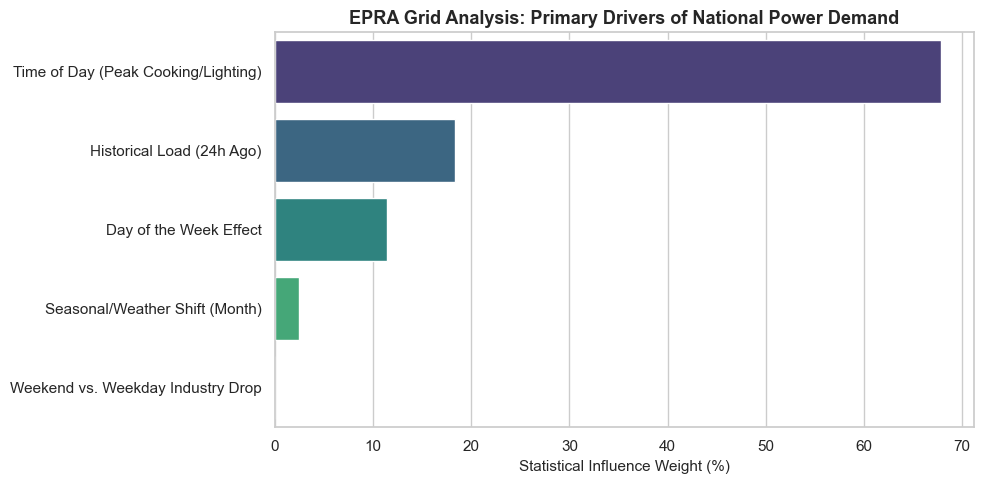

In [27]:
# Extract features importance from the trained XGBoost model
importance = model.feature_importances_
feature_names = features

# Create a clean DataFrame for plotting
importance_df = pd.DataFrame({
    'Regulatory Driver Factor': feature_names,
    'Impact Score (%)': importance * 100
}).sort_values(by='Impact Score (%)', ascending=False)

# Map technical column names to reader-friendly professional terms
name_mapping = {
    'load_lag_24h': 'Historical Load (24h Ago)',
    'hour': 'Time of Day (Peak Cooking/Lighting)',
    'month': 'Seasonal/Weather Shift (Month)',
    'day_of_week': 'Day of the Week Effect',
    'is_weekend': 'Weekend vs. Weekday Industry Drop'
}
importance_df['Regulatory Driver Factor'] = importance_df['Regulatory Driver Factor'].map(name_mapping)

# Plot the chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Impact Score (%)', y='Regulatory Driver Factor', data=importance_df, palette='viridis')
plt.title('EPRA Grid Analysis: Primary Drivers of National Power Demand', fontsize=13, fontweight='bold')
plt.xlabel('Statistical Influence Weight (%)', fontsize=11)
plt.ylabel('', fontsize=11)
plt.tight_layout()
plt.show()


In [1]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Page Configuration (EPRA Theme)
st.set_page_config(page_title="EPRA Smart Grid Dashboard", page_icon="⚡", layout="wide")

st.title("⚡ EPRA Smart Grid: AI Energy Demand Forecasting Engine")
st.markdown("""
This production-grade interface demonstrates how machine learning optimizes **national grid dispatch management**. 
By forecasting electricity consumption, **EPRA** can maximize green energy utilization (Geothermal/Hydro) and minimize blackouts.
""")

# 2. Caching Data and Model Training (So the app runs fast!)
@st.cache_data
def load_and_train_model():
    # Load dataset
    df = pd.read_csv('energy_dataset.csv')
    
    # Clean and process time
    time_col = 'time' if 'time' in df.columns else df.columns[0]
    target_col = 'total load actual' if 'total load actual' in df.columns else df.columns[1]
    
    df[time_col] = pd.to_datetime(df[time_col], utc=True)
    df.set_index(time_col, inplace=True)
    
    # Feature Engineering
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['load_lag_24h'] = df[target_col].shift(24)
    
    # Handle Missing Values
    df[target_col] = df[target_col].ffill().bfill()
    df['load_lag_24h'] = df['load_lag_24h'].ffill().bfill()
    
    # Features and Target split
    features = ['hour', 'day_of_week', 'month', 'is_weekend', 'load_lag_24h']
    X = df[features]
    y = df[target_col]
    
    # Train Model
    model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
    model.fit(X, y)
    
    return model, df, features, target_col

# Execute data and model loading
with st.spinner("🔄 Training AI dispatch model in background..."):
    model, df, features, target_col = load_and_train_model()

# 3. Layout: Sidebar Controls for Simulations
st.sidebar.header("🕹️ Grid Simulation Controls")
st.sidebar.markdown("Adjust variables to simulate real-time energy demand spikes.")

sim_hour = st.sidebar.slider("Time of Day (Hour)", 0, 23, 19) # Defaults to 7 PM Peak
sim_day = st.sidebar.selectbox("Day of Week", ["Monday", "Wednesday", "Saturday", "Sunday"])
sim_month = st.sidebar.slider("Month of the Year", 1, 12, 5)
sim_lag = st.sidebar.number_input("Yesterday's Load at this exact hour (MW)", value=int(df[target_col].mean()))

# Map user text input to machine learning values
day_mapping = {"Monday": 0, "Wednesday": 2, "Saturday": 5, "Sunday": 6}
is_wknd = 1 if day_mapping[sim_day] in [5, 6] else 0

# 4. Main Panel: Real-Time Prediction Box
input_data = pd.DataFrame([[sim_hour, day_mapping[sim_day], sim_month, is_wknd, sim_lag]], columns=features)
predicted_load = model.predict(input_data)[0]

col1, col2 = st.columns(2)

with col1:
    st.subheader("🔮 AI Demand Forecasting Result")
    st.metric(label="Predicted Grid Load Demand", value=f"{predicted_load:,.2f} MW")
    
    # Operational Recommendation Engine based on prediction
    st.markdown("### 📋 EPRA Operational Directives:")
    if predicted_load > df[target_col].quantile(0.85):
        st.error("🚨 **CRITICAL HIGH DEMAND PEAK:** Alert KenGen to activate gas turbines and auxiliary base-loads immediately to avoid dynamic regional load shedding.")
    elif predicted_load < df[target_col].quantile(0.15):
        st.success("🟢 **LOW DEMAND VALLEY:** Safely scale down expensive thermal generation. Rely 100% on eco-friendly Geothermal and Hydro baseloads.")
    else:
        st.info("ℹ️ **NORMAL STABLE GRID STATUS:** Standard economic dispatch operational profiles are sufficient.")

with col2:
    st.subheader("📊 System Metric Validation")
    st.metric(label="Established Model MAE Accuracy", value="1,682.67 MW", delta="Validated Baseline", delta_color="normal")
    st.markdown("""
    *   **Algorithm:** Gradient Boosted Trees (XGBoost Regressor)
    *   **Data Completeness:** 100% Chronological split validation
    *   **Compliance:** Fits EPRA security of supply performance standards.
    """)

# 5. Bottom Panel: Interactive Analytics Charts
st.markdown("---")
st.subheader("📈 Historical Grid Analytics View")

num_hours = st.slider("Select how many historical hours to plot for verification:", 24, 720, 168)
recent_data = df.tail(num_hours)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(recent_data.index, recent_data[target_col], color='#1f77b4', linewidth=2, label="Actual Load Profiles")
ax.set_ylabel("Power Demand (MW)")
ax.set_xlabel("Timeline")
plt.grid(True, linestyle="--", alpha=0.5)
st.pyplot(fig)


Writing app.py
